<a href="https://colab.research.google.com/github/edwardoughton/GeoAI/blob/main/09_01_ggs590_geoai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺️ Week 9 GeoAI: Segmenting satellite imagery with the Segment Anything Model (SAM) 🗺️

This notebook follows the same NAIP workflow used in week 8: we search the Microsoft Planetary Computer for NAIP imagery, select the latest scene overlapping a bounding box, and clip a small image directly from that scene.

The new part is that we then pass the clipped image to the `segment-geospatial` package, which is a Python wrapper for the Segment Anything Model (SAM), so we can then attempt to automatically segment objects and regions in the image.

Rather than focusing on only one type of location, this notebook compares segmentation across several very different places so you can see how the same model behaves in urban, rural, agricultural, and industrial settings.

Your task in the class assignment is to try to improve on the initial segmentation, using any strategies at your disposal.  


## Learning objectives

By the end of today you should be able to:

- Explain what SAM is doing at a high level.
- Search for and clip NAIP imagery from a bounding box.
- Run automatic segmentation on small aerial image clips.
- Compare segmentation behavior across contrasting landscapes.
- Export segmentation polygons to a common GIS format (e.g., GeoPackage) for later analysis.
- Design your own segmentation experiment for another location.


## What is SAM and the `segment-geospatial` package?

The Segment Anything Model (SAM) (developed by Meta) is a foundation model for image segmentation. Thus, it can identify and outline objects in images with minimal or no extra training on those objects.

SAM was trained on roughly 11 million images with 1 billion masks. The idea is to have a generalizable, reusable segmentation model for images.

By contrast, `segment-geospatial` (also known in PyPI as `SamGeo`) is a Python wrapper around SAM.

At a high level, the automatic workflow looks like this:

1. A model examines the image and proposes many candidate masks.
2. The package scores and filters those masks based on internal quality rules.
3. The masks are written to a raster output where different objects can have different integer IDs.
4. Those raster segments can then be converted into vector polygons for GIS use.

This does not mean the package already knows which polygons are buildings, roads, trees, or parking lots. And as you will see, we achieve varying degrees of success!

SAM is undertaking segmentation, not proper classification of land cover types. That means we still need interpretation, filtering, critical thinking skills, and quality control afterward.


## Install necessary packages

Uncomment and run this cell if needed.

The `segment-geospatial` documentation shows the `SamGeo` class being used for automatic mask generation and export.

In [1]:
%pip install -U pystac-client planetary-computer rasterio matplotlib geopandas "segment-geospatial[samgeo]"

## Import necessary packages

Let us import the packages we need into this notebook.

In [2]:
import os # common for file handling
from pathlib import Path # for handling file paths in a platform-independent way

import matplotlib.pyplot as plt # for plotting
import numpy as np # for numerical operations
import rasterio # for working with raster data

from pystac_client import Client # for accessing STAC APIs
import planetary_computer as pc # for accessing Microsoft Planetary Computer
from rasterio.windows import from_bounds, transform as window_transform # for raster windows
from rasterio.warp import transform_bounds # transforming bounding boxes between CRS

from samgeo import SamGeo # for working with the Segment Anything Model (SAM)



## Helper functions

These functions reuse the same logic pattern from week 8 for NAIP access and clipping, then add a plotting helper for quick visual review.

In [3]:
def bbox_overlap_area(bbox_a, bbox_b):
    """ Calculate the area of overlap between two bounding boxes.
    Each bbox is a tuple of (minx, miny, maxx, maxy).
    """
    minx = max(bbox_a[0], bbox_b[0])
    miny = max(bbox_a[1], bbox_b[1])
    maxx = min(bbox_a[2], bbox_b[2])
    maxy = min(bbox_a[3], bbox_b[3])
    if minx >= maxx or miny >= maxy:
        return 0.0
    return (maxx - minx) * (maxy - miny)


def get_latest_naip_item(bbox, datetime="2021-01-01/2025-12-31"):
    """ Search the Planetary Computer STAC API for NAIP items
    that intersect the given bbox and datetime range.
    Return the item with the latest datetime, and if there are
    multiple with the same datetime, return the one with the
    largest bbox overlap.
    """
    catalog = Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=pc.sign_inplace,
    )

    items = list(
        catalog.search(
            collections=["naip"],
            bbox=bbox,
            datetime=datetime,
            limit=12,
            method="POST",
        ).items()
    )

    if not items:
        raise ValueError("No NAIP scenes found for the requested bbox and date range.")

    latest_date = max(item.datetime for item in items if item.datetime).date()
    same_day_items = [item for item in items if item.datetime and item.datetime.date() == latest_date]
    return max(same_day_items, key=lambda item: bbox_overlap_area(bbox, item.bbox))


def read_naip_clip(item, bbox, write_path=None):
    """ Read a NAIP item from the Planetary Computer,
    clip it to the given bbox, and optionally write
    it to disk. Returns the clipped image as a numpy
    array and the rasterio profile."""
    href = item.assets["image"].href

    with rasterio.open(href) as src:
        minx, miny, maxx, maxy = transform_bounds("EPSG:4326", src.crs, *bbox)
        window = from_bounds(minx, miny, maxx, maxy, src.transform)
        window = window.round_offsets().round_lengths()
        bands = src.read(window=window)

        if bands.shape[1] == 0 or bands.shape[2] == 0:
            raise ValueError("The requested bbox produced an empty image. Try a different location.")

        profile = src.profile.copy()
        profile.update(
            height=bands.shape[1],
            width=bands.shape[2],
            count=bands.shape[0],
            transform=window_transform(window, src.transform),
        )

        if write_path is not None:
            os.makedirs(os.path.dirname(write_path) or ".", exist_ok=True)
            with rasterio.open(write_path, "w", **profile) as dst:
                dst.write(bands)

    return bands, profile


def show_rgb(image_path, ax=None, title=None):
    """ Read a geospatial image and display it as RGB."""
    with rasterio.open(image_path) as src:
        rgb = src.read([1, 2, 3]).astype("float32")
    rgb = np.moveaxis(rgb, 0, -1)
    rgb = rgb / max(rgb.max(), 1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(rgb)
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title)
    return ax


def plot_segments(image_path, mask_path, title=None, figsize=(7, 7)):
    """ Plot the original image with the SAM segmentation mask overlaid."""
    fig, ax = plt.subplots(figsize=figsize)
    show_rgb(image_path, ax=ax, title=title)

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    masked = np.ma.masked_where(mask == 0, mask)
    ax.imshow(masked, cmap="tab20", alpha=0.45)
    ax.set_axis_off()
    plt.tight_layout()
    return fig


## Initialize the segmentation model

The `SamGeo` object wraps the segmentation model and provides a range of methods we can utilize, from automatically producing masks through to quickly exporting polygons.

* `model_type="vit_b"` - This chooses the SAM backbone. SamGeo supports vit_h, vit_l, and vit_b. In general, vit_b is the smallest/lightest option, while vit_l and especially vit_h tend to be stronger but heavier. If your segmentation quality is disappointing, moving from vit_b to vit_l or vit_h is one of the biggest quality levers.
* `automatic=True` - This tells SamGeo to use the automatic mask generator over the full image, rather than prompt-based segmentation. That is why parameters like points_per_side and pred_iou_thresh matter here.
* `device="cpu"` - This affects speed and memory, not the intended algorithmic behavior. CPU is usually much slower. If you have CUDA available, using GPU is usually preferable for iteration and for trying denser settings. SamGeo itself defaults to CUDA if available.
* `sam_kwargs=sam_kwargs` - These are forwarded into the SAM automatic mask generator. The available arguments include the ones you set, plus others you did not set like points_per_batch, box_nms_thresh, crop_nms_thresh, and crop_overlap_ratio.


The key word arguments (`kwargs`) can be defined as follows:

* `points_per_side: 24` - Defines a uniform grid resolution over the image, so SAM samples points in a 24 × 24 grid, totalling 576 prompts. Each point acts like a “seed” for generating candidate masks. Higher values mean a more exhaustive segmentation, which is better for small objects, but involves slower runtime.
* `pred_iou_thresh: 0.86` - Filters masks based on predicted Intersection over Union (IoU) confidence. Then SAM internally estimates how good each mask is. Hence, only masks with predicted IoU ≥ 0.86 are kept. Higher thresholds mean fewer better quality masks (but lower thresholds mean more masks, including noisy ones).
* `stability_score_thresh: 0.92` - Measures how stable a mask is under perturbations (slight threshold changes). For example, only masks with stability ≥ 0.92 are retained. Higher values mean very clean and reliable masks. But lower values mean more masks but less consistent edges.
* `crop_n_layers: 1` - Controls multi-scale cropping of the image. For example, SAM can recursively crop the image into smaller regions to detect fine details. Thus 1 means one additional layer of crops (beyond the full image). Higher values are better for smaller objects, but also come with increased computational cost.
* `crop_n_points_downscale_factor: 2` - Reduces the number of sampled points per crop layer. For each deeper crop layer, the points_per_side = original / factor. For a value of 2, then if the base is 24, it means crops use 12 points per side. This prevents exponential growth in computation.
* `min_mask_region_area: 100` - Removes very small mask regions (in pixels), acting as a post-processing filter. Thus, any segmented region smaller than 100 pixels is discarded. Here we help to eliminate noise, but it could remove legitimate small objects if set too high.


In [4]:
output_dir = Path("week9_segmentation_outputs")
clip_dir = output_dir / "clips"
mask_dir = output_dir / "masks"
vector_dir = output_dir / "vectors"

for folder in [output_dir, clip_dir, mask_dir, vector_dir]:
    folder.mkdir(parents=True, exist_ok=True)

sam_kwargs = {
    "points_per_side": 24,
    "pred_iou_thresh": 0.86,
    "stability_score_thresh": 0.92,
    "crop_n_layers": 1,
    "crop_n_points_downscale_factor": 2,
    "min_mask_region_area": 100,
}

sam = SamGeo(
    model_type="vit_b", # vit_b is the most lightweight SAM model
    automatic=True,
    device="cpu",
    sam_kwargs=sam_kwargs,
)

## Example: Segmenting an urban neighborhood

This example contains dense residential buildings and street patterns. Notice whether the segments follow individual roofs, blocks, yards, or shadows.

Inspect the segmentation achieved, consider the areas that were or were not segmented effectively, and start to think how you might improve on this!

Site: urban_neighborhood
NAIP date: 2023-10-11
NAIP item: va_m_3807714_ne_18_060_20231011_20240103
Vector export: week9_segmentation_outputs/vectors/urban_neighborhood_segments.gpkg


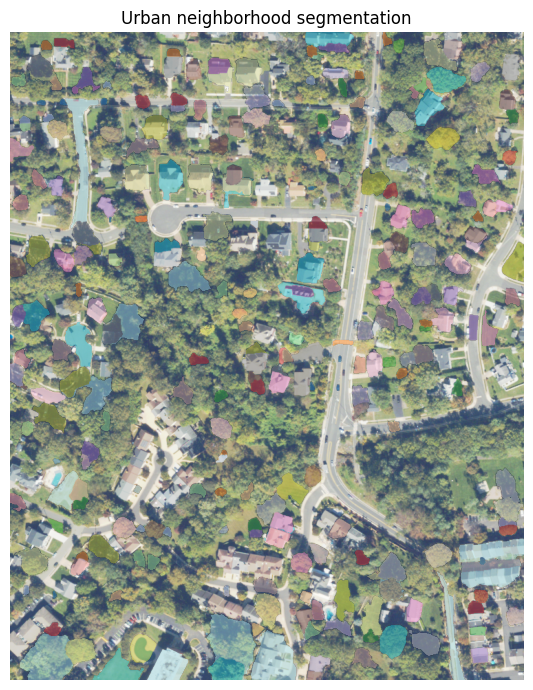

In [5]:
site_name = "urban_neighborhood"
# bbox_original = (-77.3135, 38.8465, -77.3035, 38.8565)
bbox = (-77.3110, 38.8490, -77.3060, 38.8540)

image_path = clip_dir / f"{site_name}.tif"
mask_path = mask_dir / f"{site_name}_mask.tif"
vector_path = vector_dir / f"{site_name}_segments.gpkg"

item = get_latest_naip_item(bbox, datetime="2023-01-01/2024-12-31")
bands, profile = read_naip_clip(item, bbox, write_path=str(image_path))

sam_kwargs = {
    "points_per_side": 24,
    "pred_iou_thresh": 0.86,
    "stability_score_thresh": 0.92,
    "crop_n_layers": 1,
    "crop_n_points_downscale_factor": 2,
    "min_mask_region_area": 1000,
}

sam = SamGeo(
    model_type="vit_b",
    automatic=True,
    device="cpu",
    sam_kwargs=sam_kwargs,
)

sam.generate(str(image_path), output=str(mask_path), foreground=True, unique=True)
sam.tiff_to_gpkg(str(mask_path), str(vector_path), simplify_tolerance=None)

print("Site:", site_name)
print("NAIP date:", item.datetime.date())
print("NAIP item:", item.id)
print("Vector export:", vector_path)

plot_segments(str(image_path), str(mask_path), title="Urban neighborhood segmentation");

## Example: Rural settlement

This rural example has wide open spaces between few structures. Compare the scale and shape of the segments with the urban example.

Site: rural_settlement
NAIP date: 2023-10-23
NAIP item: va_m_3807823_ne_17_060_20231023_20240103
Vector export: week9_segmentation_outputs/vectors/rural_settlement_segments.gpkg


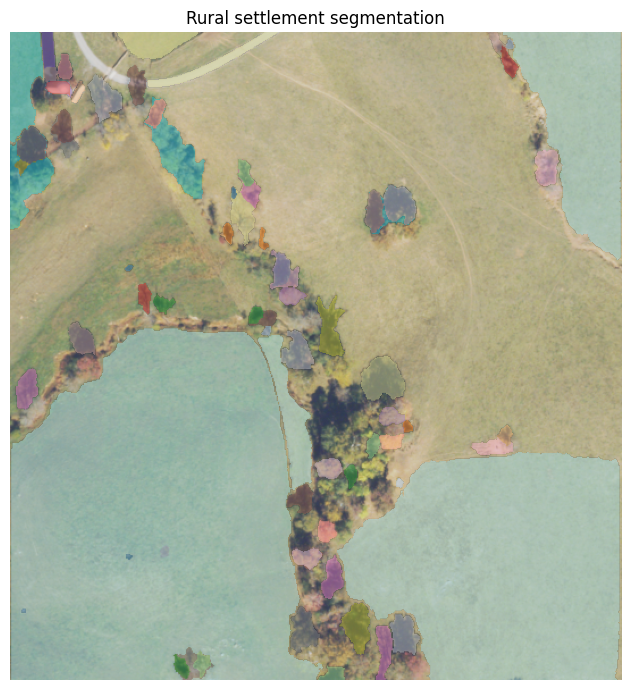

In [6]:
# Set location
site_name = "rural_settlement"
# bbox_original = (-78.1590, 38.6960, -78.1518, 38.7020)
bbox = (-78.1572, 38.6975, -78.1536, 38.7005)

# Define output paths
image_path = clip_dir / f"{site_name}.tif"
mask_path = mask_dir / f"{site_name}_mask.tif"
vector_path = vector_dir / f"{site_name}_segments.gpkg"

# Get the latest NAIP item for the site
item = get_latest_naip_item(bbox)
bands, profile = read_naip_clip(item, bbox, write_path=str(image_path))

# Run SAM segmentation
sam.generate(str(image_path), output=str(mask_path), foreground=True, unique=True)
sam.tiff_to_gpkg(str(mask_path), str(vector_path), simplify_tolerance=None)

# Print outputs and plot results
print("Site:", site_name)
print("NAIP date:", item.datetime.date())
print("NAIP item:", item.id)
print("Vector export:", vector_path)
plot_segments(str(image_path), str(mask_path), title="Rural settlement segmentation");

## Example: Agricultural fields

Large agricultural fields often produce broad, clean segments. This is useful for seeing how the package behaves when the landscape has strong boundaries but relatively few small objects.

In [ ]:
site_name = "agricultural_fields"
bbox_original = (-76.1195, 39.2305, -76.1118, 39.2367)


image_path = clip_dir / f"{site_name}.tif"
mask_path = mask_dir / f"{site_name}_mask.tif"
vector_path = vector_dir / f"{site_name}_segments.gpkg"

item = get_latest_naip_item(bbox)
bands, profile = read_naip_clip(item, bbox, write_path=str(image_path))

sam.generate(str(image_path), output=str(mask_path), foreground=True, unique=True)
sam.tiff_to_gpkg(str(mask_path), str(vector_path), simplify_tolerance=None)

print("Site:", site_name)
print("NAIP date:", item.datetime.date())
print("NAIP item:", item.id)
print("Vector export:", vector_path)

plot_segments(str(image_path), str(mask_path), title="Agricultural field segmentation");

## Example: Port or industrial waterfront

A port or waterfront-industrial landscape is useful because it contains sharp edges, paved surfaces, containers, roofs, water boundaries, and shadow patterns. This is a good stress test for segmentation.

In [ ]:
site_name = "Baltimore County, Maryland"
# bbox_original = (-76.5720, 39.2685, -76.5635, 39.2748)
bbox = (-76.569875, 39.270075, -76.565625, 39.273225)

image_path = clip_dir / f"{site_name}.tif"
mask_path = mask_dir / f"{site_name}_mask.tif"
vector_path = vector_dir / f"{site_name}_segments.gpkg"

item = get_latest_naip_item(bbox)
bands, profile = read_naip_clip(item, bbox, write_path=str(image_path))

sam.generate(str(image_path), output=str(mask_path), foreground=True, unique=True)
sam.tiff_to_gpkg(str(mask_path), str(vector_path), simplify_tolerance=None)

print("Site:", site_name)
print("NAIP date:", item.datetime.date())
print("NAIP item:", item.id)
print("Vector export:", vector_path)

plot_segments(str(image_path), str(mask_path), title="Port / industrial segmentation");

## Example: Airport runway

This example provides a different perspective, consisting of part of a runway (paved and relatively well defined). It is useful for seeing whether SAM prefers large surface regions or breaks them into smaller segments.

In [ ]:
site_name = "airport_surface"
bbox = (-77.4685, 38.9355, -77.4595, 38.9425)

image_path = clip_dir / f"{site_name}.tif"
mask_path = mask_dir / f"{site_name}_mask.tif"
vector_path = vector_dir / f"{site_name}_segments.gpkg"

item = get_latest_naip_item(bbox)
bands, profile = read_naip_clip(item, bbox, write_path=str(image_path))

sam.generate(str(image_path), output=str(mask_path), foreground=True, unique=True)
sam.tiff_to_gpkg(str(mask_path), str(vector_path), simplify_tolerance=None)

print("Site:", site_name)
print("NAIP date:", item.datetime.date())
print("NAIP item:", item.id)
print("Vector export:", vector_path)

plot_segments(str(image_path), str(mask_path), title="Airport / transportation segmentation");

## Example: High density woodland

This example is of a dense tree canopy. It is useful for seeing whether the segmentation follows the canopy texture.

In [ ]:
site_name = "forest_edge"
bbox = (-78.0815, 38.9240, -78.0738, 38.9300)

image_path = clip_dir / f"{site_name}.tif"
mask_path = mask_dir / f"{site_name}_mask.tif"
vector_path = vector_dir / f"{site_name}_segments.gpkg"

item = get_latest_naip_item(bbox)
bands, profile = read_naip_clip(item, bbox, write_path=str(image_path))

sam.generate(str(image_path), output=str(mask_path), foreground=True, unique=True)
sam.tiff_to_gpkg(str(mask_path), str(vector_path), simplify_tolerance=None)

print("Site:", site_name)
print("NAIP date:", item.datetime.date())
print("NAIP item:", item.id)
print("Vector export:", vector_path)

plot_segments(str(image_path), str(mask_path), title="Forest edge segmentation");

## Example: Stadium or sports complex

A sports complex combines large engineered surfaces, parking lots, fields, and crisp boundaries. It is useful for seeing whether the model treats the site as a few large objects or many smaller segments.

In [ ]:
site_name = "sports_complex"
bbox = (-76.623284, 39.331236, -76.617941, 39.334224)

image_path = clip_dir / f"{site_name}.tif"
mask_path = mask_dir / f"{site_name}_mask.tif"
vector_path = vector_dir / f"{site_name}_segments.gpkg"

item = get_latest_naip_item(bbox)
bands, profile = read_naip_clip(item, bbox, write_path=str(image_path))

sam.generate(str(image_path), output=str(mask_path), foreground=True, unique=True)
sam.tiff_to_gpkg(str(mask_path), str(vector_path), simplify_tolerance=None)

print("Site:", site_name)
print("NAIP date:", item.datetime.date())
print("NAIP item:", item.id)
print("Vector export:", vector_path)

plot_segments(str(image_path), str(mask_path), title="Sports complex segmentation");

## Exercise

For one of the examples covered, try to work out how to improve the segmentation by tweaking the parameters available with the `Sam`/`SamGeo` package.

If you complete this, you could try choosing a new image for a different season (if available), and exploring the impact.

## Exercise

Now choose a new location of your own and repeat the workflow using a small bbox. Try to pick a landscape type we have not already tested.

Possibilities include:

- dense downtown blocks,
- suburban sprawl,
- forest edge,
- shoreline or marsh,
- quarry or mine,
- solar farm.

Your task is to:

1. define a small bbox,
2. run segmentation,
3. inspect the final matplotlib image,
4. export the `.gpkg`,
5. write 3-5 sentences explaining what segmented well and what did not.